In [1]:
import os
import zipfile
from pathlib import Path
import shutil
import xarray as xr

In [3]:
base_path = Path(os.getcwd())
repo_root = base_path.parents[3]
print(f"Current working directory: {base_path}")
print(f"Repository root directory: {repo_root}")

Current working directory: c:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT\Duomenu_mokslo_projektas\code\python\datasets_prep
Repository root directory: c:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT


In [6]:
SOURCE_DIR = os.path.join(repo_root, "CAMS_Downloads", "Dust")
TARGET_DIR = os.path.join(repo_root, "CAMS unzip", "dust")

os.makedirs(TARGET_DIR, exist_ok=True)

for file_name in os.listdir(SOURCE_DIR):
    if file_name.endswith(".zip"):
        zip_path = os.path.join(SOURCE_DIR, file_name)
        
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            internal_files = zip_ref.namelist()
            
            nc_files = [f for f in internal_files if f.endswith('.nc')]
            
            for nc_file in nc_files:
                target_file_name = file_name.replace(".zip", ".nc")
                
                source = zip_ref.open(nc_file)
                target_path = os.path.join(TARGET_DIR, target_file_name)
                
                with open(target_path, "wb") as target:
                    shutil.copyfileobj(source, target)
                
                print(f"Extracted and flattened: {target_file_name}")

print("\nDone! All .nc files are now in:", TARGET_DIR)

Extracted and flattened: cams_2018_01_dust_validated.nc
Extracted and flattened: cams_2018_02_dust_validated.nc
Extracted and flattened: cams_2018_03_dust_validated.nc
Extracted and flattened: cams_2018_04_dust_validated.nc
Extracted and flattened: cams_2018_05_dust_validated.nc
Extracted and flattened: cams_2018_06_dust_validated.nc
Extracted and flattened: cams_2018_07_dust_validated.nc
Extracted and flattened: cams_2018_08_dust_validated.nc
Extracted and flattened: cams_2018_09_dust_validated.nc
Extracted and flattened: cams_2018_10_dust_validated.nc
Extracted and flattened: cams_2018_11_dust_validated.nc
Extracted and flattened: cams_2018_12_dust_validated.nc
Extracted and flattened: cams_2019_01_dust_validated.nc
Extracted and flattened: cams_2019_02_dust_validated.nc
Extracted and flattened: cams_2019_03_dust_validated.nc
Extracted and flattened: cams_2019_04_dust_validated.nc
Extracted and flattened: cams_2019_05_dust_validated.nc
Extracted and flattened: cams_2019_06_dust_valid

In [8]:
file_path = r"C:\Users\crist\Documents\VU, Data Science\6 semestras\Duomenu mokslo projektas\GIT\CAMS unzip\dust\cams_2018_07_dust_validated.nc"

ds = xr.open_dataset(file_path)
print(ds)

<xarray.Dataset> Size: 113kB
Dimensions:  (time: 744, lat: 6, lon: 6)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2018-07-01 ... 2018-07-31T23:00:00
  * lat      (lat) float64 48B 54.4 54.5 54.6 54.7 54.8 54.9
  * lon      (lon) float64 48B 25.0 25.1 25.2 25.3 25.4 25.5
Data variables:
    dust     (time, lat, lon) float32 107kB ...
Attributes:
    Conventions:  CF-1.7
    Title:        CAMS European air quality validated reanalysis
    Provider:     COPERNICUS European air quality service
    Production:   COPERNICUS Atmosphere Monitoring Service


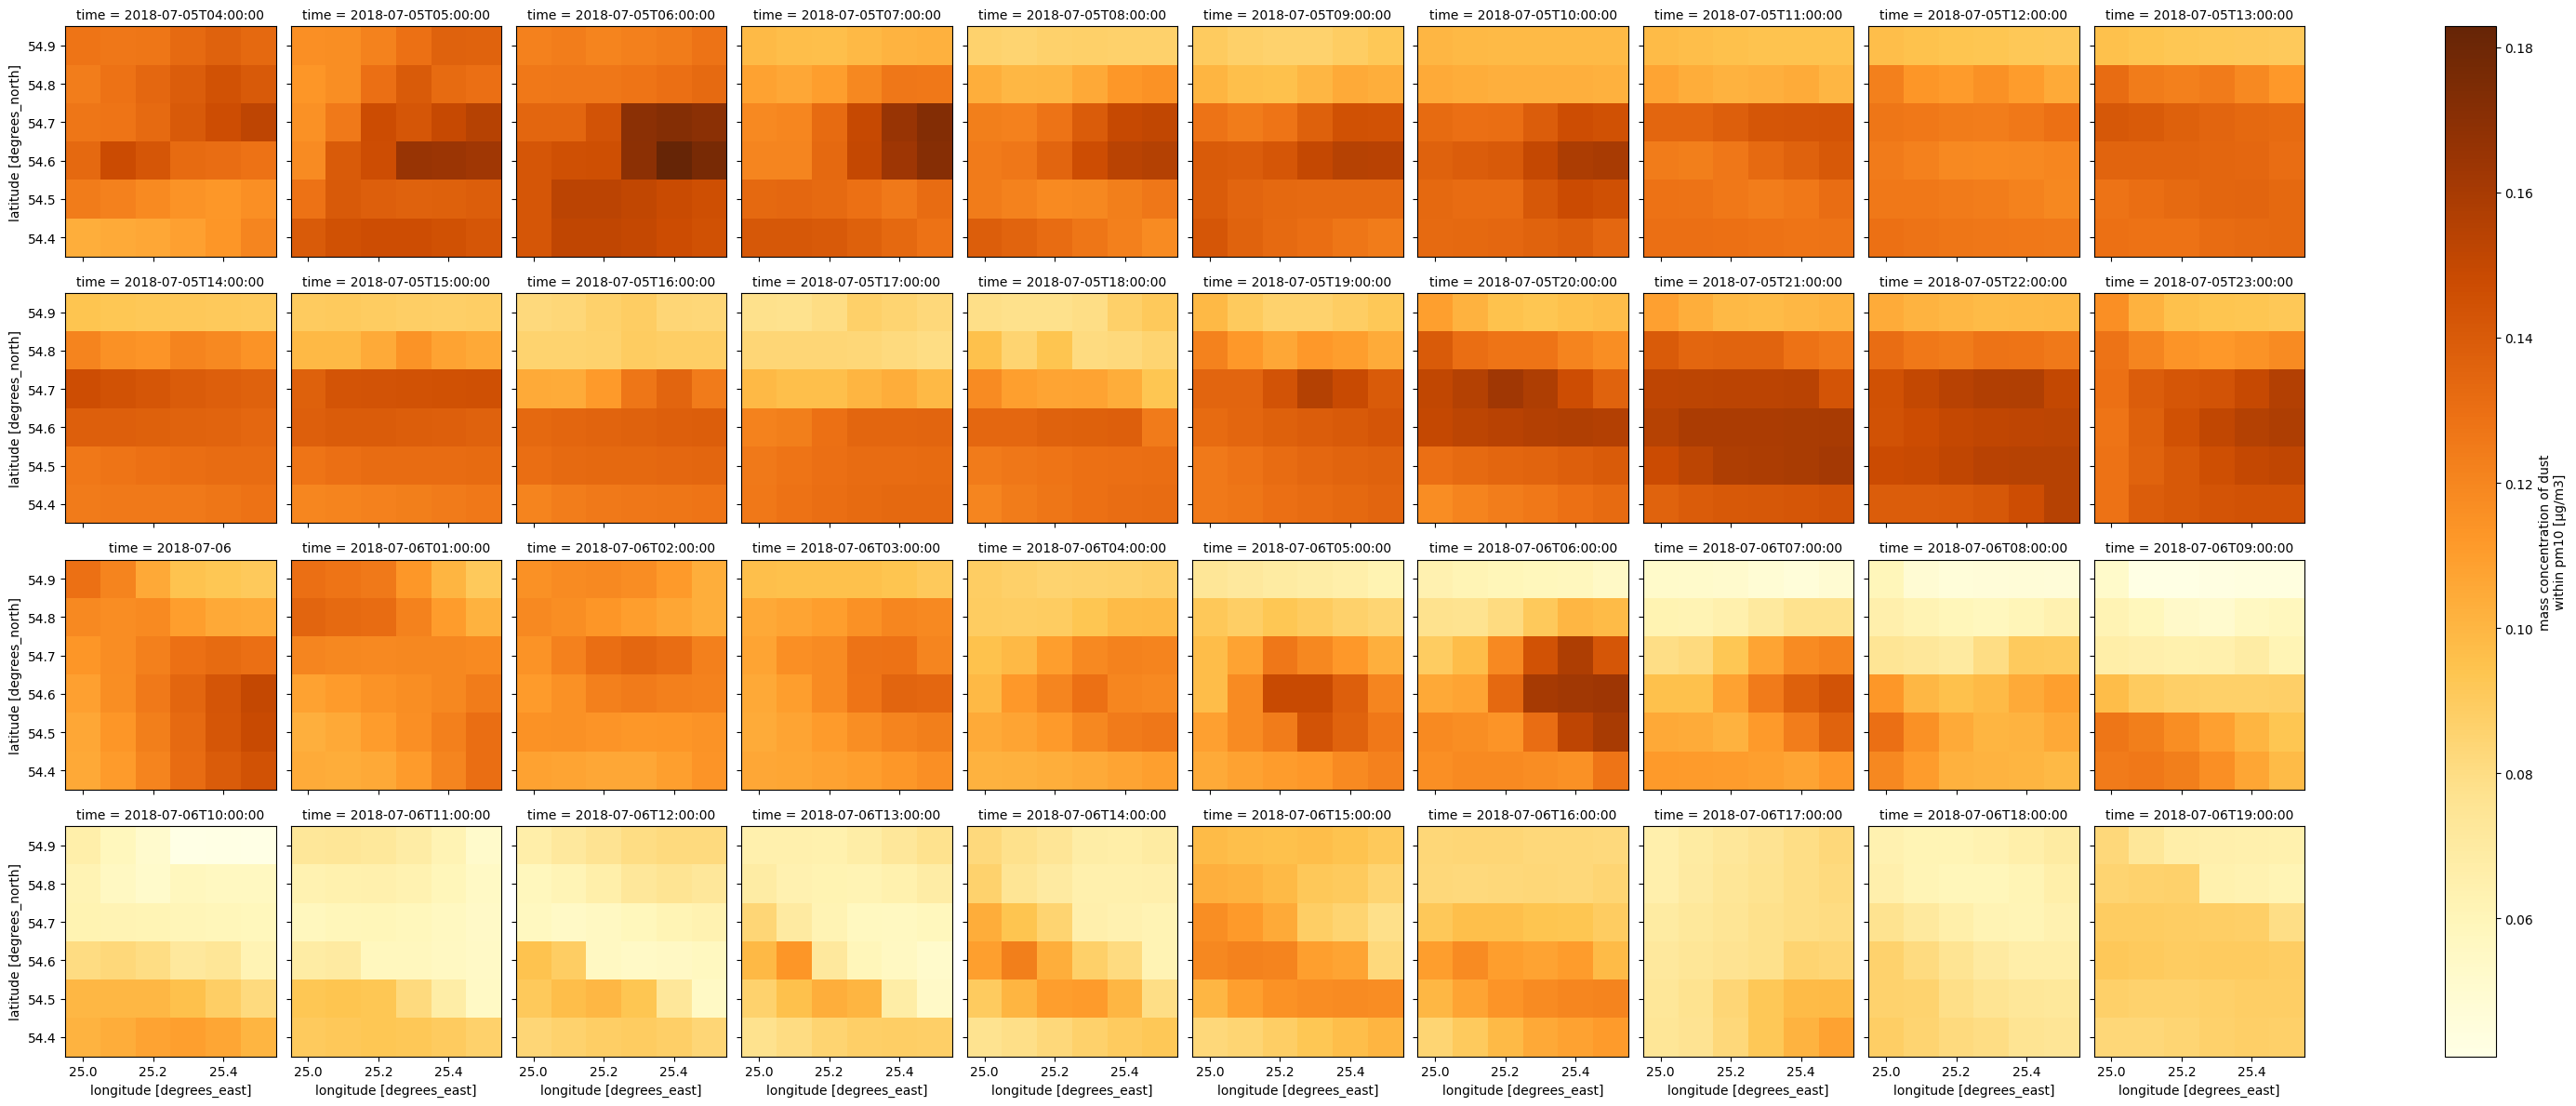

In [9]:
import matplotlib.pyplot as plt

plot = ds.dust.isel(time=slice(100, 140)).plot(
    col="time", 
    col_wrap=10, 
    cmap="YlOrBr"
)

plt.show()